<a href="https://colab.research.google.com/github/Arisa-Laloo/CSE3120Project/blob/main/Arisa_Laloo_crowd_simulation_with_robot_arm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Approach
In order for the robot to find the main point od evacuation, clustering is applied to particles near the exists. The particles are filtered based on their proximity to the exits to ensure only those attempting to leave are considered. For each particle $x_i$, the distance to the nearest exit is computed using:

##$$d^{exit}_i = \min_{k}||x_i-e_k||$$

Particles statisfying: $d^{exit}_i < d_{thresh}$ are classified as escaping particles.


#Clustering Method
K-means clustering is applied to the positions in particles in ℇ. This partitions a set of points into $k$ cluster by minimizing the variance within the cluster.

### $$\sum_{c=1}^{k} \sum_{x_i \in c} \|x_i - \mu_c\|^2 $$

where $μ_c$ is the center of the cluster $c$

#Clustering Selection
After clustering the robot selects the cluster representing the most significant evacuation flow which is determined by:
$$c^* = \arg\max_c N_c$$
where $N_c$ is the number of particles n cluster $c$.

The center of the cluster is computed by:
##$$μ_c = \frac{1}{N_c}∑_{x_iϵc}x_i$$

The robot uses the the cluster center as the estimate for the dominant evacuation stream.

#Prediction Model
The robot anticipates where a cluster will be in the fiture in order to intercept the evacutation flow.
##Cluster Velocity
Let $μ_c(t)$ be the cluster center at time $t$ and $μ_c(t-Δt)$ the center at the previous time stamp, then the cluster velocity is estimated as:
$$v_c(t) = \frac{μ_c(t) - μ_c(t-Δt)}{Δt}$$
##Future Velocity Prediction
The predicted future position of hte cluster is computed using linear extrapolation:
###$$\hatμ_c(t+T_p) = U_c(t) T_p · v_c(t)$$
where:
- $T_p$ is a fixed parameter controlling how far ahead the robot anticipates motion.

#Robot Crowd Interaction
The robot arm responds to crowd behavior near exits and influences the movements of the agents through the cost function.

###Target Selection
The robot identifies clusters of agents near exits and selects the largest cluster then predicts the fututre position of the cluster. This becomes the target. It is modeled by:
$$x^{target}_{robot} = \hatμ_c(t+T_p)$$

###Motion Generation
The robot moves towards the target using inverse kinematics. A jacobian-based method is used to iteratively update joint angles:
$$ø_{t+1} = ø_t+J^{†}Δx$$
where:
* J^{†} is the pseudoinverse of the jacobian
* ΔX is the displacement toward the target

### Interaction via Cost Function
Th robot influences the crowd through a rupulsions term in the agent cost function. For each agent $i$, the interaction is modeled as:
$$
C_{\text{robot}}(x_i) =
\begin{cases}
w_r \left( \frac{1}{d_i + \epsilon} - \frac{1}{R} \right)^2, & d_i < R \\
0, & d_i \ge R
\end{cases}
$$

where:
* $d_i  = ||x_i-x_{robot}||$ is the distance to the robot end effector
* $R$ is the influence radius
* $w_r$ controld the strength of the interaction

### Effect on Agent Motion
The robot modifies agent trajectories by altering the gradient of the total cost function:
$$C_i = C_{goal}+C_{walls}+C_{height}+C_{smooth}+C_{robot}$$
This results in the agents avoiding the robot's space, trajectories being deflected around the robot and the redistribution of the congestion near the exits


In [23]:

# Install required libraries
!pip install -q vedo imageio

In [24]:

import os
import glob
import numpy as np
import imageio.v2 as imageio

from vedo import Plotter, Box, Mesh, Sphere, Light, load, LinearTransform
from IPython.display import Image, display

try:
    import vedo
    if "google.colab" in str(get_ipython()):
        vedo.settings.init_colab()
        if vedo.settings.default_backend != "vtk":
            vedo.settings.default_backend = "vtk"
except:
    pass

setting up colab environment (can take a minute) ...installing k3d... setup completed.


In [25]:

# =========================================================
# PARAMETERS
# =========================================================
H = 4.0
W = 20.0
D = 13.0

AGENT_R = 0.18
AGENT_Z_OFFSET = AGENT_R + 0.03
SLAB_T  = 0.14
WALL_T  = 0.22
INNER_H = 0.95

FRONT_WALL_H = 0.85
SIDE_WALL_H  = 1.15
BACK_WALL_H  = 2.10

RAMP_W  = 1.8
RAMP_T  = 0.16

CLR_FLOOR_G = "#d6d6d6"
CLR_FLOOR_1 = "#d0d0d0"
CLR_FLOOR_2 = "#cacaca"

CLR_WALL_OUT = "#f3f3f3"
CLR_WALL_IN  = "#fafafa"
CLR_RAMP     = "#8B5A2B"
CLR_AGENT    = "#4f79b8"

In [26]:

# =========================================================
# NAVIGATION WAYPOINTS / EXITS
# =========================================================
TOP_RAMP_ENTRANCES = np.array([
    [2.8, 2.8, 2*H],
    [5.8, 2.8, 2*H],
], dtype=float)

MID_RAMP_ENTRANCES = np.array([
    [13.2, 2.6, H],
    [16.1, 2.6, H],
], dtype=float)

TOP_WAYPOINT_A = np.array([9.2, 11.1, 2*H], dtype=float)
TOP_WAYPOINT_B = np.array([7.4, 6.6, 2*H], dtype=float)

MID_WAYPOINT_A = np.array([8.2, 3.8, H], dtype=float)
MID_WAYPOINT_B = np.array([12.2, 3.0, H], dtype=float)

GROUND_WAYPOINT = np.array([12.8, 2.2, 0.0], dtype=float)

EXITS = np.array([
    [14.2, 0.35, 0.0],
    [17.8, 0.35, 0.0],
], dtype=float)

In [27]:

# =========================================================
# FLOOR PATCHES + RAMPS + 2D WALLS
# =========================================================
FLOOR_PATCHES = []

FLOOR_PATCHES.append((0.0, W, 0.0, D, 0.0))

mid_opening = (12.2, 19.0, 2.0, 6.8)
x0, x1, y0, y1 = mid_opening
FLOOR_PATCHES += [
    (0.0, x0, 0.0, D, H),
    (x1, W, 0.0, D, H),
    (x0, x1, 0.0, y0, H),
    (x0, x1, y1, D, H),
]

top_opening = (1.8, 8.8, 2.0, 6.8)
x0, x1, y0, y1 = top_opening
FLOOR_PATCHES += [
    (0.0, x0, 0.0, D, 2*H),
    (x1, W, 0.0, D, 2*H),
    (x0, x1, 0.0, y0, 2*H),
    (x0, x1, y1, D, 2*H),
]

RAMPS = [
    {"A": np.array([2.8, 2.8]),  "B": np.array([5.0, 6.0]),  "z0": 2*H, "z1": H,   "r": RAMP_W/2},
    {"A": np.array([5.8, 2.8]),  "B": np.array([8.0, 6.0]),  "z0": 2*H, "z1": H,   "r": RAMP_W/2},
    {"A": np.array([13.2, 2.6]), "B": np.array([15.1, 6.2]), "z0": H,   "z1": 0.0, "r": RAMP_W/2},
    {"A": np.array([16.1, 2.6]), "B": np.array([18.0, 6.2]), "z0": H,   "z1": 0.0, "r": RAMP_W/2},
]

WALLS_BY_FLOOR = {0.0: [], H: [], 2*H: []}

ground_openings = [(13.2, 16.0)]
first_openings  = [(12.4, 16.2)]
second_openings = [(9.4, 14.2)]

def collect_outer_shell(front_openings):
    walls = [((0, 0), (0, D)), ((W, 0), (W, D)), ((0, D), (W, D))]
    xcur = 0.0
    for a, b in front_openings:
        if a > xcur:
            walls.append(((xcur, 0), (a, 0)))
        xcur = b
    if xcur < W:
        walls.append(((xcur, 0), (W, 0)))
    return walls

returns = [
    ((0.0, 0.0), (0.0, 2.2)),
    ((0.0, 0.0), (2.2, 0.0)),
    ((0.0, 10.8), (0.0, D)),
]

ground_segments = [
    ((2.2, 2.0), (2.2, 10.8)),
    ((2.2, 10.8), (7.4, 10.8)),
    ((7.2, 3.0), (7.2, 8.6)),
    ((7.2, 8.6), (11.0, 8.6)),
    ((11.0, 4.2), (11.0, 10.8)),
    ((13.6, 8.0), (18.2, 8.0)),
    ((14.4, 2.3), (18.0, 2.3)),
]

first_segments = [
    ((2.2, 8.0), (8.2, 8.0)),
    ((8.6, 4.2), (8.6, 11.0)),
    ((11.2, 9.0), (17.8, 9.0)),
    ((3.0, 10.8), (6.8, 10.8)),
]

second_segments = [
    ((9.8, 2.4), (9.8, 10.5)),
    ((9.8, 7.8), (17.6, 7.8)),
    ((13.6, 2.3), (17.4, 2.3)),
    ((11.8, 5.0), (16.6, 5.0)),
]

WALLS_BY_FLOOR[0.0] += collect_outer_shell(ground_openings) + returns + ground_segments
WALLS_BY_FLOOR[H]   += collect_outer_shell(first_openings)  + returns + first_segments
WALLS_BY_FLOOR[2*H] += collect_outer_shell(second_openings) + returns + second_segments

In [28]:

# =========================================================
# SCENE / GEOMETRY HELPERS
# =========================================================
def make_floor_piece(xmin, xmax, ymin, ymax, z_top, thickness, color, alpha=0.92):
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    sx = xmax - xmin
    sy = ymax - ymin
    zc = z_top - thickness / 2
    return (
        Box(pos=(cx, cy, zc), length=sx, width=sy, height=thickness)
        .c(color)
        .alpha(alpha)
        .lighting("default")
    )

def add_floor_with_opening(actors, z_top, color, opening, alpha=0.92):
    x0, x1, y0, y1 = opening
    if x0 > 0:
        actors.append(make_floor_piece(0, x0, 0, D, z_top, SLAB_T, color, alpha))
    if x1 < W:
        actors.append(make_floor_piece(x1, W, 0, D, z_top, SLAB_T, color, alpha))
    if y0 > 0 and x1 > x0:
        actors.append(make_floor_piece(x0, x1, 0, y0, z_top, SLAB_T, color, alpha))
    if y1 < D and x1 > x0:
        actors.append(make_floor_piece(x0, x1, y1, D, z_top, SLAB_T, color, alpha))

def wall_from_segment(p1, p2, zbase, height, thickness=WALL_T, color=CLR_WALL_IN):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    L = np.hypot(dx, dy)
    if L < 1e-8:
        return None

    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    ang = np.degrees(np.arctan2(dy, dx))

    w = Box(pos=(cx, cy, zbase + height / 2), length=L, width=thickness, height=height).c(color).lighting("default")
    w.rotate_z(ang)
    return w

def make_ramp(A, B, zA, zB, width=RAMP_W, thickness=RAMP_T, color=CLR_RAMP):
    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float)
    v = B - A
    L = np.linalg.norm(v)
    if L < 1e-8:
        raise ValueError("Ramp endpoints must be distinct.")

    u = v / L
    n = np.array([-u[1], u[0]])
    hw = width / 2.0

    p1 = np.array([A[0] + hw*n[0], A[1] + hw*n[1], zA])
    p2 = np.array([A[0] - hw*n[0], A[1] - hw*n[1], zA])
    p3 = np.array([B[0] - hw*n[0], B[1] - hw*n[1], zB])
    p4 = np.array([B[0] + hw*n[0], B[1] + hw*n[1], zB])

    q1 = p1 - np.array([0, 0, thickness])
    q2 = p2 - np.array([0, 0, thickness])
    q3 = p3 - np.array([0, 0, thickness])
    q4 = p4 - np.array([0, 0, thickness])

    verts = [p1, p2, p3, p4, q1, q2, q3, q4]
    faces = [
        [0, 1, 2], [0, 2, 3],
        [4, 6, 5], [4, 7, 6],
        [0, 4, 5], [0, 5, 1],
        [1, 5, 6], [1, 6, 2],
        [2, 6, 7], [2, 7, 3],
        [3, 7, 4], [3, 4, 0],
    ]

    ramp = Mesh([verts, faces]).c(color).lighting("plastic")
    ramp.lw(1)
    return ramp

def add_wall_list(actors, segs, zbase, h, color):
    for a, b in segs:
        w = wall_from_segment(a, b, zbase, h, color=color)
        if w is not None:
            actors.append(w)

def add_outer_shell(actors, zbase, front_openings):
    for seg, height in [(((0, 0), (0, D)), SIDE_WALL_H),
                        (((W, 0), (W, D)), SIDE_WALL_H),
                        (((0, D), (W, D)), BACK_WALL_H)]:
        w = wall_from_segment(seg[0], seg[1], zbase, height, color=CLR_WALL_OUT)
        if w is not None:
            actors.append(w)

    xcur = 0.0
    for a, b in front_openings:
        if a > xcur:
            w = wall_from_segment((xcur, 0), (a, 0), zbase, FRONT_WALL_H, color=CLR_WALL_OUT)
            if w is not None:
                actors.append(w)
        xcur = b

    if xcur < W:
        w = wall_from_segment((xcur, 0), (W, 0), zbase, FRONT_WALL_H, color=CLR_WALL_OUT)
        if w is not None:
            actors.append(w)

def add_left_return_walls(actors, zbase):
    returns_local = [
        ((0.0, 0.0), (0.0, 2.2)),
        ((0.0, 0.0), (2.2, 0.0)),
        ((0.0, 10.8), (0.0, D)),
    ]
    add_wall_list(actors, returns_local, zbase, SIDE_WALL_H, CLR_WALL_OUT)

In [29]:

# =========================================================
# BUILD STATIC BUILDING ACTORS
# =========================================================
actors = []

actors.append(make_floor_piece(0, W, 0, D, 0.0, SLAB_T, CLR_FLOOR_G, alpha=0.92))
add_floor_with_opening(actors, H, CLR_FLOOR_1, (12.2, 19.0, 2.0, 6.8), alpha=0.88)
add_floor_with_opening(actors, 2*H, CLR_FLOOR_2, (1.8, 8.8, 2.0, 6.8), alpha=0.86)

add_outer_shell(actors, 0.0, ground_openings)
add_outer_shell(actors, H, first_openings)
add_outer_shell(actors, 2*H, second_openings)

add_left_return_walls(actors, 0.0)
add_left_return_walls(actors, H)
add_left_return_walls(actors, 2*H)

add_wall_list(actors, ground_segments, 0.0, INNER_H, CLR_WALL_IN)
add_wall_list(actors, first_segments, H, INNER_H, CLR_WALL_IN)
add_wall_list(actors, second_segments, 2*H, INNER_H, CLR_WALL_IN)

actors.append(make_ramp((2.8, 2.8), (5.0, 6.0), 2*H, H, color=CLR_RAMP))
actors.append(make_ramp((5.8, 2.8), (8.0, 6.0), 2*H, H, color=CLR_RAMP))
actors.append(make_ramp((13.2, 2.6), (15.1, 6.2), H, 0.0, color=CLR_RAMP))
actors.append(make_ramp((16.1, 2.6), (18.0, 6.2), H, 0.0, color=CLR_RAMP))

In [30]:

# =========================================================
# SURFACE MODEL
# =========================================================
def point_in_rect(x, y, rect):
    xmin, xmax, ymin, ymax, _ = rect
    return xmin <= x <= xmax and ymin <= y <= ymax

def ramp_projection_data(x, y, ramp):
    A = ramp["A"]
    B = ramp["B"]
    r = ramp["r"]
    v = B - A
    L = np.linalg.norm(v)
    if L < 1e-12:
        return None

    u = v / L
    w = np.array([x, y]) - A
    s = np.dot(w, u)
    perp = np.linalg.norm(w - s*u)

    return {"L": L, "u": u, "s": s, "s_clamped": np.clip(s, 0.0, L), "perp": perp, "inside": (0.0 <= s <= L and perp <= r)}

def zramp(x, y, ramp):
    data = ramp_projection_data(x, y, ramp)
    lam = data["s_clamped"] / data["L"]
    return (1 - lam) * ramp["z0"] + lam * ramp["z1"]

def candidate_surface_heights(x, y):
    vals = []
    for rect in FLOOR_PATCHES:
        if point_in_rect(x, y, rect):
            vals.append(rect[4])
    for ramp in RAMPS:
        data = ramp_projection_data(x, y, ramp)
        if data["inside"]:
            vals.append(zramp(x, y, ramp))
    return vals

def zsurf(x, y, z_current):
    vals = candidate_surface_heights(x, y)
    if len(vals) == 0:
        levels = np.array([0.0, H, 2*H])
        return levels[np.argmin(np.abs(levels - z_current))]
    vals = np.array(vals)
    return vals[np.argmin(np.abs(vals - z_current))]

def current_floor_level(z):
    levels = np.array([0.0, H, 2*H])
    return levels[np.argmin(np.abs(levels - z))]

In [31]:

# =========================================================
# COST TERMS + GRADIENT
# =========================================================
tau = 1.0
ww = 1.8
wh = 2.0
ws = 0.03
wr = 0.0
wall_band = 0.35

repulsion_radius = 0.8
repulsion_eps = 1e-6

def softmin_sqdist(p, targets, tau=1.0):
    vals = np.array([np.sum((p - q)**2) for q in targets], dtype=float)
    return -tau * np.log(np.sum(np.exp(-vals / tau)) + 1e-12)

def dist_point_segment_2d(p, a, b):
    p = np.array(p, dtype=float)
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    ab = b - a
    L2 = np.dot(ab, ab)
    if L2 < 1e-12:
        return np.linalg.norm(p - a)
    t = np.clip(np.dot(p - a, ab) / L2, 0.0, 1.0)
    proj = a + t * ab
    return np.linalg.norm(p - proj)

def goal_cost(p):
    x, y, z = p
    if z > 1.5 * H:
        if x > 9.4:
            return 35.0 * np.sum((p - TOP_WAYPOINT_A)**2)
        elif y > 6.8:
            return 30.0 * np.sum((p - TOP_WAYPOINT_B)**2)
        else:
            return 30.0 * softmin_sqdist(p, TOP_RAMP_ENTRANCES, tau=tau)
    elif z > 0.5 * H:
        if x < 8.6 and y > 4.2:
            return 35.0 * np.sum((p - MID_WAYPOINT_A)**2)
        elif x < 12.4:
            return 30.0 * np.sum((p - MID_WAYPOINT_B)**2)
        else:
            return 30.0 * softmin_sqdist(p, MID_RAMP_ENTRANCES, tau=tau)
    else:
        if x < 13.0 and y > 2.0:
            return 20.0 * np.sum((p - GROUND_WAYPOINT)**2)
        return 35.0 * softmin_sqdist(p, EXITS, tau=tau)

def wall_cost(p):
    zf = current_floor_level(p[2])
    c = 0.0
    for a, b in WALLS_BY_FLOOR[zf]:
        d = dist_point_segment_2d(p[:2], a, b)
        if d < wall_band:
            c += ww * (wall_band - d)**2
    return c

def height_cost(p):
    return wh * (p[2] - zsurf(p[0], p[1], p[2]))**2

def smooth_cost(p, p_prev):
    return ws * np.sum((p - p_prev)**2)

def repulsion_cost(i, positions):
    pi = positions[i]
    c = 0.0
    for j in range(len(positions)):
        if i == j:
            continue
        d = np.linalg.norm(pi - positions[j])
        if d < repulsion_radius:
            c += wr * (1.0/(d + repulsion_eps) - 1.0/repulsion_radius)**2
    return c

fd_eps = 0.06
step_size = 0.12
max_step = 0.22
momentum_beta = 0.35

In [32]:

# =========================================================
# ROBOT ARM CLASS
# =========================================================
class RobotArm:
    def __init__(self, partLengths, parts, arm_location, radius=0.04, wrist_offset=-0.43):
        self.arm_location = np.array(arm_location, dtype=float)
        self.L1, self.L2, self.L3, self.L4 = partLengths
        self.source_parts = parts
        self.radius = radius
        self.wrist_offset = wrist_offset
        self.delta_phi = 0.25
        self.target = np.array([14.5, 1.0, 1.0], dtype=float)
        self.target_lambda = 0.35
        self.meshes = None
        self.initialize_meshes()

    def initialize_meshes(self):
        self.meshes = [p.clone() for p in self.source_parts]

    def RotationMatrix(self, theta, axis_name):
        c = np.cos(theta * np.pi / 180.0)
        s = np.sin(theta * np.pi / 180.0)
        if axis_name == "x":
            return np.array([[1, 0, 0],[0, c, -s],[0, s, c]])
        elif axis_name == "y":
            return np.array([[c, 0, s],[0, 1, 0],[-s, 0, c]])
        elif axis_name == "z":
            return np.array([[c, -s, 0],[s, c, 0],[0, 0, 1]])
        else:
            raise ValueError(axis_name)

    def getLocalFrameMatrix(self, R_ij, t_ij):
        return np.block([[R_ij, t_ij],[np.zeros((1, 3)), np.array([[1]])]])

    def forward_kinematics(self, Phi):
        phi1, phi2, phi3, phi4 = Phi
        R_00 = self.RotationMatrix(0, "z")
        t_00 = np.copy(self.arm_location)
        t_00[-1] = 0
        T_00 = self.getLocalFrameMatrix(R_00, t_00)

        R_01 = self.RotationMatrix(phi1, "z")
        t_01 = self.arm_location
        T_01 = self.getLocalFrameMatrix(R_01, t_01)

        R_12 = self.RotationMatrix(phi2, "y")
        t_12 = np.array([[0.0], [0.0], [self.L1 + 2*self.radius]])
        T_12 = self.getLocalFrameMatrix(R_12, t_12)
        T_02 = T_01 @ T_12

        R_23 = self.RotationMatrix(phi3, "y")
        t_23 = np.array([[0.0], [0.0], [self.L2 + 2*self.radius]])
        T_23 = self.getLocalFrameMatrix(R_23, t_23)
        T_03 = T_01 @ T_12 @ T_23

        R_34 = self.RotationMatrix(phi4, "y")
        t_34 = np.array([[self.wrist_offset], [0.0], [self.L3 + self.radius]])
        T_34 = self.getLocalFrameMatrix(R_34, t_34)
        T_04 = T_01 @ T_12 @ T_23 @ T_34

        e = T_04[0:3, -1]
        return T_00, T_01, T_02, T_03, T_04, e

    def get_pose_transforms(self, Phi):
        T_00, T_01, T_02, T_03, _, _ = self.forward_kinematics(Phi)
        return [T_00, T_01, T_02, T_03]

    def update_pose(self, Phi):
        transforms = self.get_pose_transforms(Phi)
        new_meshes = [p.clone() for p in self.source_parts]
        for mesh, T in zip(new_meshes, transforms):
            mesh.apply_transform(LinearTransform(T))
        self.meshes = new_meshes
        return self.meshes

    def jacobian_matrix(self, phi):
        step = self.delta_phi
        _, _, _, _, _, e = self.forward_kinematics(phi)
        Jcols = []
        for k in range(3):
            dphi = np.zeros(4)
            dphi[k] = step
            _, _, _, _, _, e2 = self.forward_kinematics(phi + dphi)
            Jcols.append(((e2 - e) / step).reshape(3, 1))
        return np.concatenate(Jcols, axis=1)

    def ik_step(self, phi):
        phi = np.array(phi, dtype=float).copy()
        _, _, _, _, _, e = self.forward_kinematics(phi)
        J = self.jacobian_matrix(phi)
        phi_delta = np.linalg.pinv(J) @ (self.target_lambda * (self.target - e))
        phi = phi + np.append(phi_delta, [0.0])
        return phi

In [33]:

# =========================================================
# CLUSTERING + PREDICTION + ROBOT COST
# =========================================================
EXIT_CLUSTER_DIST = 3.0
GROUND_Z_THRESH = 0.8
PREDICTION_HORIZON = 3.0
K_CLUSTERS = 2

w_robot = 20.0
robot_repulsion_radius = 1.8
robot_repulsion_eps = 1e-6
robot_effector_pos = np.array([10.0, 1.0, 1.0], dtype=float)

def get_particles_near_exits(positions, active, exit_dist_thresh=EXIT_CLUSTER_DIST):
    idx = np.where(active)[0]
    if len(idx) == 0:
        return np.array([], dtype=int)
    pos = positions[idx]
    ground_mask = pos[:, 2] <= GROUND_Z_THRESH
    dxy = np.linalg.norm(pos[:, None, :2] - EXITS[None, :, :2], axis=2)
    near_exit = np.min(dxy, axis=1) < exit_dist_thresh
    return idx[ground_mask & near_exit]

def kmeans_np(X, k=2, n_iter=20, seed=0):
    if len(X) == 0:
        return None, None
    if len(X) < k:
        k = len(X)
    rng_local = np.random.default_rng(seed)
    centers = X[rng_local.choice(len(X), size=k, replace=False)].copy()
    for _ in range(n_iter):
        d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(d, axis=1)
        new_centers = centers.copy()
        for j in range(k):
            pts = X[labels == j]
            if len(pts) > 0:
                new_centers[j] = pts.mean(axis=0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    labels = np.argmin(d, axis=1)
    return labels, centers

def select_largest_cluster(points3d, labels, centers):
    best_j = max(range(len(centers)), key=lambda j: np.sum(labels == j))
    cluster_pts = points3d[labels == best_j]
    cluster_center = cluster_pts.mean(axis=0)
    return best_j, cluster_pts, cluster_center

def predict_cluster_position(center_now, center_prev, dt=1.0, horizon=PREDICTION_HORIZON):
    if center_prev is None:
        return center_now.copy()
    v = (center_now - center_prev) / dt
    return center_now + horizon * v

def robot_cost(p, robot_pos):
    if robot_pos is None:
        return 0.0
    d = np.linalg.norm(p - robot_pos)
    if d < robot_repulsion_radius:
        return w_robot * (1.0/(d + robot_repulsion_eps) - 1.0/robot_repulsion_radius)**2
    return 0.0

def total_cost(i, p, positions, p_prev, robot_pos=None):
    old = positions[i].copy()
    positions[i] = p
    c = (
        goal_cost(p)
        + wall_cost(p)
        + height_cost(p)
        + smooth_cost(p, p_prev)
        + repulsion_cost(i, positions)
        + robot_cost(p, robot_pos)
    )
    positions[i] = old
    return c

def finite_difference_grad_xy(i, p, positions, p_prev, robot_pos=None, eps=fd_eps):
    g = np.zeros(2)

    for k in range(2):
        dp = np.zeros(3)
        dp[k] = eps

        p_plus = p.copy()
        p_minus = p.copy()

        p_plus[:2] += dp[:2]
        p_minus[:2] -= dp[:2]

        p_plus[2] = zsurf(p_plus[0], p_plus[1], p[2]) + AGENT_Z_OFFSET
        p_minus[2] = zsurf(p_minus[0], p_minus[1], p[2]) + AGENT_Z_OFFSET

        c_plus = total_cost(i, p_plus, positions, p_prev, robot_pos)
        c_minus = total_cost(i, p_minus, positions, p_prev, robot_pos)

        g[k] = (c_plus - c_minus) / (2 * eps)

    return g

def reached_exit(p, tol=0.):
    return abs(p[2]) < 0.4 and np.min(np.linalg.norm(EXITS - p, axis=1)) < tol

In [34]:

# =========================================================
# INITIAL AGENTS
# =========================================================
rng = np.random.default_rng(4)
spawn_regions = [
    ((2.8, 6.8),  (2.5, 7.5),  0.0),
    ((8.5, 10.5), (3.5, 6.0),  0.0),
    ((3.0, 7.0),  (8.4, 10.3), H),
    ((10.5, 16.5),(9.4, 10.5), H),
    ((11.0, 15.5),(3.0, 6.2),  2*H),
    ((11.0, 16.0),(8.2, 10.0), 2*H),
]

def sample_from_region(region):
    (xmin, xmax), (ymin, ymax), z0 = region
    x = rng.uniform(xmin, xmax)
    y = rng.uniform(ymin, ymax)
    z = zsurf(x, y, z0) + AGENT_Z_OFFSET
    return np.array([x, y, z], dtype=float)

N = 24
positions = np.array([sample_from_region(spawn_regions[i % len(spawn_regions)]) for i in range(N)])
prev_positions = positions.copy()
vel = np.zeros_like(positions)
active = np.ones(N, dtype=bool)

In [35]:

# =========================================================
# ROBOT MESH DOWNLOAD + SETUP
# =========================================================
ROBOT_SCALE = 0.005
robot_dir = "robot/"
if not os.path.exists(robot_dir):
    !wget -O robot.zip "https://www.dropbox.com/scl/fi/uewvrcempf2wf2jp7bcb8/robot.zip?rlkey=7uwz1ne94hxyinub8x16y93em&dl=1"
    !unzip -o robot.zip
    !rm robot.zip

Base    = load(robot_dir + "Base.stl").scale(ROBOT_SCALE).color("blue5")
BaseRot = load(robot_dir + "BaseRot.stl").scale(ROBOT_SCALE).color("lightblue")
Humerus = load(robot_dir + "Humerus.stl").scale(ROBOT_SCALE).color("gray5")
Radius  = load(robot_dir + "Radius.stl").scale(ROBOT_SCALE).color("red5")

robot_parts = [Base, BaseRot, Humerus, Radius]

BaseRotH = 81.0
HumerusH = 217.0
RadiusH  = 416.0
L = [BaseRotH * ROBOT_SCALE, HumerusH * ROBOT_SCALE, RadiusH * ROBOT_SCALE, 0.0]

arm_location = np.array([[15.0], [-1.2], [0.0]], dtype=float)

robot = RobotArm(L, robot_parts, arm_location, radius=0.4 * ROBOT_SCALE, wrist_offset=-20.0 * ROBOT_SCALE)
robot_phi = np.array([0.0, 25.0, -35.0, 0.0], dtype=float)
_, _, _, _, _, robot_effector_pos = robot.forward_kinematics(robot_phi)
robot_meshes = robot.update_pose(robot_phi)

In [36]:

# =========================================================
# RENDER ACTORS
# =========================================================
building_actors = actors[:]
agent_actors = [Sphere(pos=p, r=AGENT_R, c=CLR_AGENT).lighting("default") for p in positions]

robot_target_actor = Sphere(pos=robot.target, r=0.18, c="red")
robot_effector_actor = Sphere(pos=robot_effector_pos, r=0.22, c="purple")
cluster_actor = Sphere(pos=(0, 0, -10), r=0.16, c="orange")
pred_actor = Sphere(pos=(0, 0, -10), r=0.18, c="green")

In [37]:
# Save identical initial conditions for repeated experiments
positions_init = positions.copy()
prev_positions_init = prev_positions.copy()
vel_init = vel.copy()
active_init = active.copy()
robot_phi_init = robot_phi.copy()

In [38]:
def run_current_simulation(USE_ROBOT, frames_dir="frames_tmp", save_frames=False):
    global positions, prev_positions, vel, active, robot_phi

    # reset state
    positions = positions_init.copy()
    prev_positions = prev_positions_init.copy()
    vel = vel_init.copy()
    active = active_init.copy()
    robot_phi = robot_phi_init.copy()

    # reset actors
    for i, s in enumerate(agent_actors):
        s.pos(positions[i])

    # reset histories
    mean_speed_history = []
    active_count_history = []
    robot_target_history = []
    robot_effector_history = []
    cluster_center_history = []

    if save_frames:
        os.makedirs(frames_dir, exist_ok=True)
        for f in glob.glob(os.path.join(frames_dir, "*.png")):
            os.remove(f)

    vp = Plotter(offscreen=True, size=(1700, 1050), bg="white")
    light1 = Light(pos=(34, -20, 22), focal_point=(W/2, D/2, H), intensity=1.0)
    light2 = Light(pos=(-8, 26, 15), focal_point=(W/2, D/2, H), intensity=0.35)
    vp += light1
    vp += light2

    prev_cluster_center = None
    n_steps = 180

    for t in range(n_steps):
        new_positions = positions.copy()

        if USE_ROBOT:
            near_idx = get_particles_near_exits(positions, active, EXIT_CLUSTER_DIST)

            if len(near_idx) >= 2:
                cluster_points = positions[near_idx]
                labels, centers = kmeans_np(cluster_points[:, :3], k=K_CLUSTERS, n_iter=20, seed=t)
                _, selected_pts, cluster_center = select_largest_cluster(cluster_points, labels, centers)

                predicted_cluster_pos = predict_cluster_position(
                    cluster_center, prev_cluster_center, dt=1.0, horizon=PREDICTION_HORIZON
                )
                predicted_cluster_pos[0] = np.clip(predicted_cluster_pos[0], 0.5, W - 0.5)
                predicted_cluster_pos[1] = np.clip(predicted_cluster_pos[1], 0.3, D - 0.5)
                predicted_cluster_pos[2] = AGENT_Z_OFFSET

                max_reach = 5.0
                vec = predicted_cluster_pos - robot.arm_location.flatten()
                dist = np.linalg.norm(vec)
                if dist > max_reach:
                    predicted_cluster_pos = robot.arm_location.flatten() + (vec / dist) * max_reach

                robot.target = predicted_cluster_pos.copy()
                robot_phi = robot.ik_step(robot_phi)

                _, _, _, _, _, robot_effector_pos = robot.forward_kinematics(robot_phi)
                robot_effector_pos[0] = np.clip(robot_effector_pos[0], 0.0, W)
                robot_effector_pos[1] = np.clip(robot_effector_pos[1], -2.0, D)
                robot_effector_pos[2] = np.clip(robot_effector_pos[2], 0.0, 2 * H + 1.0)
                robot_meshes = robot.update_pose(robot_phi)

                cluster_actor.pos(cluster_center)
                pred_actor.pos(predicted_cluster_pos)
                robot_target_actor.pos(robot.target)
                robot_effector_actor.pos(robot_effector_pos)

                prev_cluster_center = cluster_center.copy()

                robot_target_history.append(robot.target.copy())
                robot_effector_history.append(robot_effector_pos.copy())
                cluster_center_history.append(cluster_center.copy())
            else:
                _, _, _, _, _, robot_effector_pos = robot.forward_kinematics(robot_phi)
                robot_meshes = robot.update_pose(robot_phi)
                robot_effector_actor.pos(robot_effector_pos)

                robot_target_history.append(robot.target.copy())
                robot_effector_history.append(robot_effector_pos.copy())
                cluster_center_history.append(None)
        else:
            robot_effector_pos = None

        for i in range(N):
            if not active[i]:
                continue

            p = positions[i].copy()
            p_prev = prev_positions[i].copy()

            gxy = finite_difference_grad_xy(
                i, p, positions, p_prev,
                robot_effector_pos if USE_ROBOT else None
            )
            vel[i, :2] = momentum_beta * vel[i, :2] - step_size * gxy
            vel[i, 2] = 0.0

            step_xy = vel[i, :2]
            step_norm = np.linalg.norm(step_xy)
            if step_norm > max_step:
                step_xy = step_xy * (max_step / step_norm)

            p_new = p.copy()
            p_new[:2] += step_xy
            p_new[0] = np.clip(p_new[0], 0.2, W - 0.2)
            p_new[1] = np.clip(p_new[1], 0.05, D - 0.2)
            p_new[2] = zsurf(p_new[0], p_new[1], p[2]) + AGENT_Z_OFFSET

            new_positions[i] = p_new

            if reached_exit(p_new):
                active[i] = False

        prev_positions = positions.copy()
        positions = new_positions

        for i, s in enumerate(agent_actors):
            s.pos(positions[i])

        speeds = np.linalg.norm(positions - prev_positions, axis=1)
        mean_speed_history.append(np.mean(speeds[active]) if np.any(active) else 0.0)
        active_count_history.append(np.sum(active))

        vp.clear()

        if USE_ROBOT:
            all_actors = (
                building_actors
                + robot_meshes
                + [robot_target_actor, robot_effector_actor, cluster_actor, pred_actor]
                + agent_actors
            )
        else:
            all_actors = building_actors + agent_actors

        vp.show(
            all_actors,
            camera={
                "pos": (4, -17, 13),
                "focal_point": (W/2, D/2, H + 0.4),
                "viewup": (0, 0, 1),
                "clipping_range": (0.1, 200),
            },
            axes=0,
            resetcam=(t == 0)
        )

        if save_frames:
            vp.screenshot(os.path.join(frames_dir, f"frame_{t:04d}.png"))

        if np.sum(active) == 0:
            break

    vp.close()

    return {
        "mean_speed_history": mean_speed_history,
        "active_count_history": active_count_history,
        "robot_target_history": robot_target_history,
        "robot_effector_history": robot_effector_history,
        "cluster_center_history": cluster_center_history,
    }

    if save_frames and video_path is not None:
        frame_files = sorted(
            [os.path.join(frames_dir, f) for f in os.listdir(frames_dir) if f.endswith(".png")]
        )

        if len(frame_files) > 0:
            with imageio.get_writer(video_path, fps=12) as writer:
                for f in frame_files:
                    writer.append_data(imageio.imread(f))

            print("Saved video:", video_path)

In [39]:
baseline_results = run_current_simulation(
    USE_ROBOT=False,
    frames_dir="frames_baseline",
    save_frames=True
)

robot_results = run_current_simulation(
    USE_ROBOT=True,
    frames_dir="frames_robot",
    save_frames=True
)

Saved video: evacuation_baseline.mp4


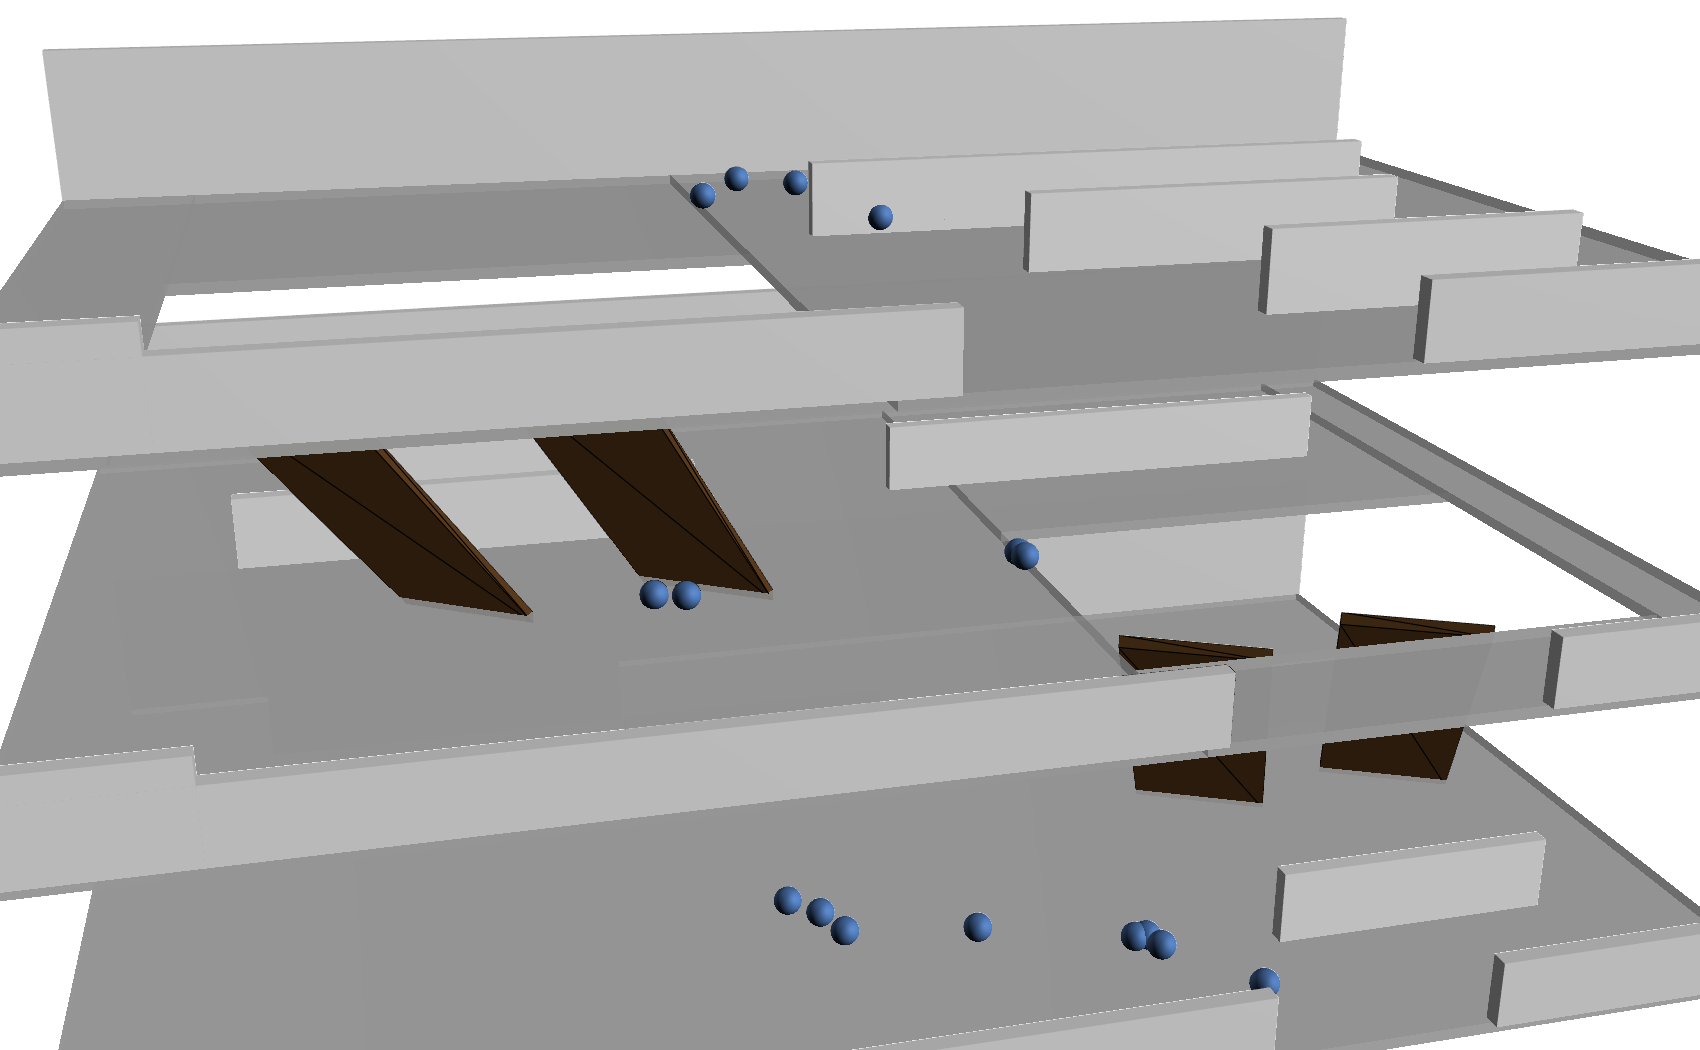

Saved video: evacuation_robot_simulation.mp4


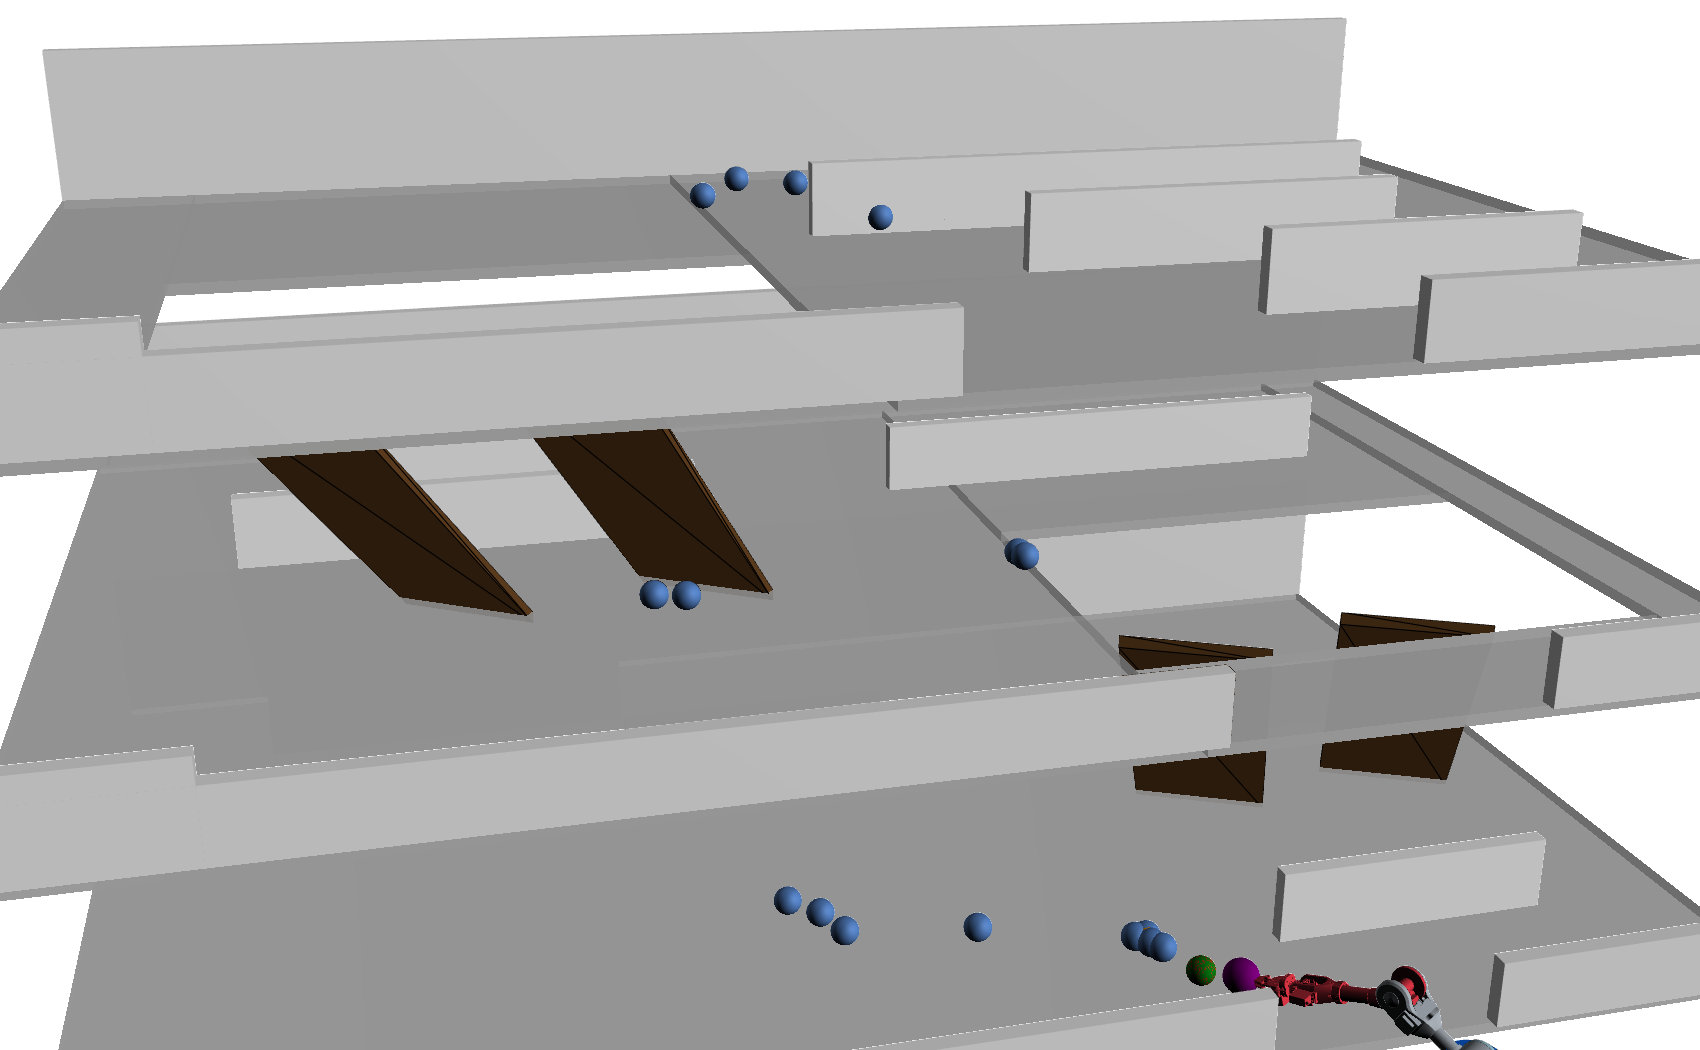

In [40]:

# =========================================================
# BUILD VIDEO
# =========================================================
frames_dir = "frames_baseline"
frame_files = sorted([os.path.join(frames_dir, f) for f in os.listdir(frames_dir) if f.endswith(".png")])

video_path = "evacuation_baseline.mp4"
with imageio.get_writer(video_path, fps=12) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

print("Saved video:", video_path)
if len(frame_files) > 0:
    display(Image(filename=frame_files[min(20, len(frame_files)-1)]))


frames_dir = "frames_robot"
frame_files = sorted([os.path.join(frames_dir, f) for f in os.listdir(frames_dir) if f.endswith(".png")])

video_path = "evacuation_robot_simulation.mp4"
with imageio.get_writer(video_path, fps=12) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

print("Saved video:", video_path)
if len(frame_files) > 0:
    display(Image(filename=frame_files[min(20, len(frame_files)-1)]))

##Link for Baseline Simulation without Robot Interference
https://youtu.be/jtKDTNXBYAY

###Link for Simulation with Robot Interference
https://youtu.be/QycFva_LVgs


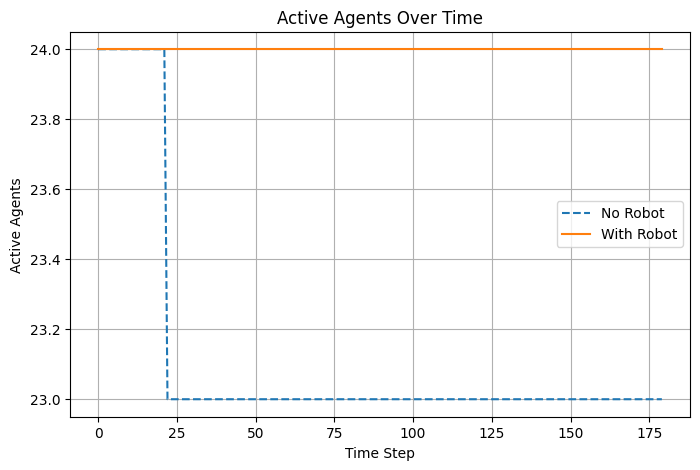

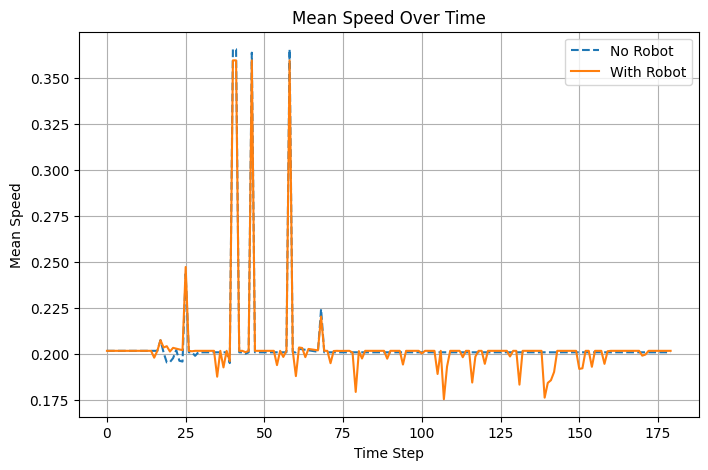

In [41]:

# =========================================================
# ANALYSIS PLOTS
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(baseline_results["active_count_history"], "--", label="No Robot")
plt.plot(robot_results["active_count_history"], label="With Robot")
plt.xlabel("Time Step")
plt.ylabel("Active Agents")
plt.title("Active Agents Over Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(baseline_results["mean_speed_history"], "--", label="No Robot")
plt.plot(robot_results["mean_speed_history"], label="With Robot")
plt.xlabel("Time Step")
plt.ylabel("Mean Speed")
plt.title("Mean Speed Over Time")
plt.legend()
plt.grid(True)
plt.show()

#Analysis
This simulation shows that the agents move through the environment but fail to successfully evacuate. A baseline experiment is done to show the agents movement before the introduction of the robot arm. Then the simulation is run again with the robot arm. The active agent count only drops by 1 in the baseline experiment. The speed over time is constant meaning the remaining agents are continuosly moving but unable to reach the exit. The video shows that many of them reach a bottleneck right before the exit. Once the robot arm is introduced, none of the particles make it to the exit. The arm acts as an obstacle disrupting the trajectories and causing conjestion near the exit. The system also shows strong clustering near the exit. The agents circulate the exit instead of dispersing in the environment .